# Results Analysis
This notebook performs data analysis on the data in the `results/` folder.

In [66]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from dataclasses import dataclass
from typing import Any

Data from each training file stored in the `results/` folder is stored in the TrainingData object, defined by the dataclass below. Some useful functions for data analysis are also stored in this dataclass.

In [97]:
# Define a dataclass to hold the training data and associated metadata
@dataclass
class TrainingData:
    training_samples: list[int]     # Number of training samples seen by the model at each step
    gradients: list[float]          # The gradient values at each training step
    loss_values: list[float]        # The loss values at each training step
    accuracies: list[float]         # This list may have different length than the others, as accuracies are only calculated once per epoch
    metadata: dict[str, Any]

    def __post_init__(self):
        # Remove leading 0 from training_samples if present
        if self.training_samples and self.training_samples[0] == 0:
            #self.training_samples = self.training_samples[1:]
            self.training_samples.pop(0)
        # Ensure that the training lists have the same length (accuracies only calcaulated once per epoch)
        lengths = [len(self.training_samples), len(self.gradients), len(self.loss_values)]
        if len(set(lengths)) != 1:
            raise ValueError("All lists must have the same length.")
        for key, value in self.metadata.items():
            assert key not in ['training_samples', 'gradients', 'loss_values', 'accuracies'], f"Metadata key '{key}' conflicts with a TrainingData attribute."
            setattr(self, key, value)
        if self.metadata.get('noise_model_object') is None:
            self.noise_model_name, self.noise_params = TrainingData.parse_noise_model(self.metadata.get('noise_model', 'none'))
        else:
            self.noise_params = self.metadata['noise_model_metadata']  # Use the metadata from the noise model object if available

    def __str__(self):
        return (f"TrainingResults(\n"
                f"metadata={self.metadata}, \n"
                f"training_samples_length={len(self.training_samples)}, gradients_length={len(self.gradients)}, "
                f"loss_values_length={len(self.loss_values)}, accuracies_length={len(self.accuracies)}\n\t)")
    
    
    @staticmethod
    def running_average(data, window_size: int):
        """Calculate the running average of the given data."""
        return np.convolve(data, np.ones(window_size)/window_size, mode='valid')
    
    @staticmethod
    def batch_average(data, batch_size: int):
        """Calculate the average of the given data in batches."""
        return [np.mean(data[i:i + batch_size]) for i in range(0, len(data), batch_size)]
    
    @staticmethod
    def parse_noise_model(noise_model: str, parse_params: bool = True) -> str|tuple[str, dict[str, float]]:
        """
        Parses a noise model string to extract a name and its specific noise parameters.

        Assumes the noise model string is formatted like `<number_of_qubits>-qubit-<noise_type>(p_depol=<value>, p_damp=<value>)`. The function extracts the noise type and its associated probability value.
        For example, if the noise model is `'single-qubit-depol(p=0.01)'`, it will return `("Single Qubit Depol", {'depolarising_noise': 0.01})`.
        """
        noise_params = {}
        if not noise_model or noise_model.lower() == "none":
            return "No Noise", noise_params
        noise_type = noise_model.split("(")[0]                       # 1. Extract the part before the '('
        noise_type = noise_type.replace("-", " ").replace("_", " ")  # 2. Replace hyphens and underscores with spaces
        noise_type = noise_type.title()                              # 3. Convert to title case
        if not parse_params:
            return noise_type, noise_params

        noise_params_str = noise_model.split('(')[1].rstrip(')')          # 4. Extract the part inside the parentheses
        noise_params_list = noise_params_str.replace(" ", "").split(",")  # 5. Split by commas to get individual parameters

        for param in noise_params_list:
            key, value = param.split("=")
            if key == "p-depol":
                noise_params['depolarising_noise'] = float(value)
            elif key == "p-damp":
                noise_params['damping_noise'] = float(value)
            # Add more parsing logic for other noise types as needed

        return noise_type, noise_params
    
    @staticmethod
    def load_from_pickle(file_path:str) -> 'TrainingData':
        """Loads training data into a TrainingData object from a pickle file. """
        assert os.path.exists(file_path), f"File {file_path} could not be found."
        assert file_path.endswith('.pkl'), f"File {file_path} is not a pickle file."

        with open(file_path, 'rb') as f:
            data = pickle.load(f)
        return TrainingData(
            training_samples = data['training_samples'],
            gradients        = data['gradients'],
            loss_values      = data['loss_values'],
            accuracies       = data['accuracies'],
            metadata         = data['metadata'],
        )
    

In [98]:
DIRECTORY = "results/"
DIRECTORY_FILE_NAMES = os.listdir(DIRECTORY)
training_files = [file for file in DIRECTORY_FILE_NAMES if file.startswith("training")]
print(training_files)

['training_qubits_10_layers_20_epochs_1_batch_1_shots_10000_noise_none.pkl', 'training_qubits_10_layers_20_epochs_1_batch_1_shots_10000_noise_single-qubit-depol(p-depol=0.000121).pkl', 'training_qubits_10_layers_20_epochs_1_batch_1_shots_10000_noise_single-qubit-depol(p-depol=0.000422).pkl', 'training_qubits_10_layers_20_epochs_1_batch_1_shots_10000_noise_single-qubit-depol(p-depol=0.00147).pkl', 'training_qubits_10_layers_20_epochs_1_batch_1_shots_10000_noise_single-qubit-depol(p-depol=0.00199).pkl', 'training_qubits_10_layers_20_epochs_1_batch_1_shots_10000_noise_single-qubit-depol(p-depol=0.00511).pkl', 'training_qubits_10_layers_20_epochs_1_batch_1_shots_10000_noise_single-qubit-depol(p-depol=1e-05).pkl', 'training_qubits_10_layers_20_epochs_1_batch_1_shots_10000_noise_single-qubit-depol(p-depol=3.48e-05).pkl']


In [99]:
training_data_list = []
for file in training_files:
    data = TrainingData.load_from_pickle(os.path.join(DIRECTORY, file))
    training_data_list.append(data)

In [116]:
training_data_list.sort(key=lambda x: x.noise_params.get('depolarising_noise', 0))  # Sorts the list by depolarising noise
print([('p_depol', data.noise_params.get('depolarising_noise', 0), data.accuracies) for data in training_data_list])
for data in training_data_list:
    print(f"Noise Model: {data.metadata['noise_model']}, Depolarising Noise: {data.noise_params.get('depolarising_noise', 0)}")

[('p_depol', 0, {10000: 0.772}), ('p_depol', 1e-05, {10000: 0.772}), ('p_depol', 3.48e-05, {10000: 0.756}), ('p_depol', 0.000121, {10000: 0.776}), ('p_depol', 0.000422, {10000: 0.788}), ('p_depol', 0.00147, {10000: 0.8}), ('p_depol', 0.00199, {10000: 0.816}), ('p_depol', 0.00511, {10000: 0.76})]
Noise Model: none, Depolarising Noise: 0
Noise Model: single-qubit-depol(p-depol=1e-05), Depolarising Noise: 1e-05
Noise Model: single-qubit-depol(p-depol=3.48e-05), Depolarising Noise: 3.48e-05
Noise Model: single-qubit-depol(p-depol=0.000121), Depolarising Noise: 0.000121
Noise Model: single-qubit-depol(p-depol=0.000422), Depolarising Noise: 0.000422
Noise Model: single-qubit-depol(p-depol=0.00147), Depolarising Noise: 0.00147
Noise Model: single-qubit-depol(p-depol=0.00199), Depolarising Noise: 0.00199
Noise Model: single-qubit-depol(p-depol=0.00511), Depolarising Noise: 0.00511


In [101]:
print(f"Length of training samples: {len(training_data_list[0].training_samples)} \nLength of accuracies: {len(training_data_list[0].accuracies)} \nLength of loss values: {len(training_data_list[0].loss_values)}\nLength of gradients: {len(training_data_list[0].gradients)}")

Length of training samples: 10000 
Length of accuracies: 1 
Length of loss values: 10000
Length of gradients: 10000


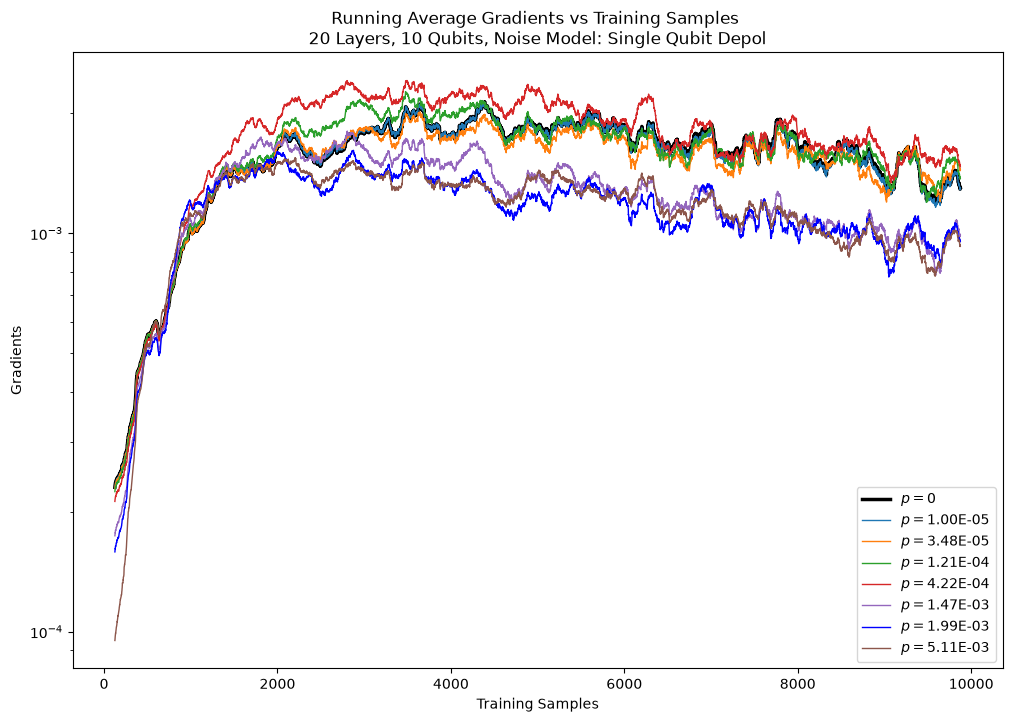

<Figure size 640x480 with 0 Axes>

In [112]:
window_size = 250 
colors = sns.color_palette(['black', 'C0', 'C1', 'C2', 'C3', 'C4', 'blue', 'C5'], len(training_data_list))  
plt.figure(figsize=(12, 8))
for data in training_data_list:
    smoothed_gradients = TrainingData.running_average(data.gradients, window_size)
    smoothed_training_samples = data.training_samples[window_size//2 - 1:-window_size//2]
    label = f'$p=${data.noise_params.get("depolarising_noise", 0):.2E}' if data.noise_params.get("depolarising_noise", 0) > 0 else '$p=0$'
    linewidth = 2.5 if data.noise_params.get("depolarising_noise", 0) == 0 else 1  # Thicker line for no depolarising noise
    plt.plot(smoothed_training_samples, smoothed_gradients, label=label, color=colors[training_data_list.index(data)], linewidth=linewidth, alpha=1)

plt.xlabel('Training Samples')
plt.ylabel('Gradients')
plt.yscale('log')
plt.title(f'Running Average Gradients vs Training Samples \n{training_data_list[0].layers} Layers, {training_data_list[0].num_qubits} Qubits, Noise Model: {training_data_list[1].noise_model_name}')
plt.legend()
plt.show()
plt.savefig('plots/runavg_gradients_vs_training_samples.pdf', dpi=300, bbox_inches='tight')

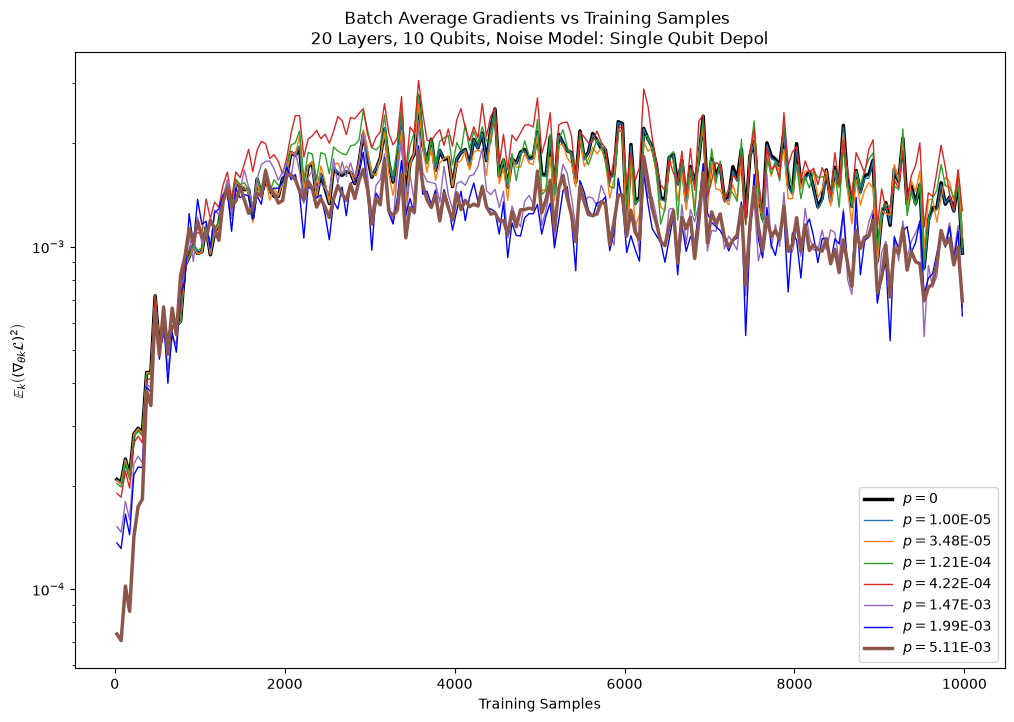

In [113]:
batches_size = 50  # Define the window size for batch average
plt.figure(figsize=(12, 8))
for data in training_data_list:
    batch_avg_gradients        = TrainingData.batch_average(data.gradients, batches_size)
    batch_avg_training_samples = TrainingData.batch_average(data.training_samples, batches_size)
    p_depol = data.noise_params.get("depolarising_noise", 0)
    label = f'$p=${p_depol:.2E}' if p_depol > 0 else '$p=0$'
    linewidth = 2.5 if (p_depol == 0 or p_depol > 5e-3) else 1  # Thicker line for no depolarising noise
    plt.plot(batch_avg_training_samples, batch_avg_gradients, label=label, color=colors[training_data_list.index(data)], linewidth=linewidth)
plt.xlabel('Training Samples')
plt.ylabel(r'$\mathbb{E}_k \left( (\nabla_{\theta k} \mathcal{L})^2 \right)$')
plt.yscale('log')
plt.legend()
plt.title(f'Batch Average Gradients vs Training Samples \n{training_data_list[0].layers} Layers, {training_data_list[0].num_qubits} Qubits, Noise Model: {training_data_list[1].noise_model_name}')
plt.savefig('plots/batchavg_gradients_vs_training_samples.pdf', dpi=300, bbox_inches='tight')
plt.show()

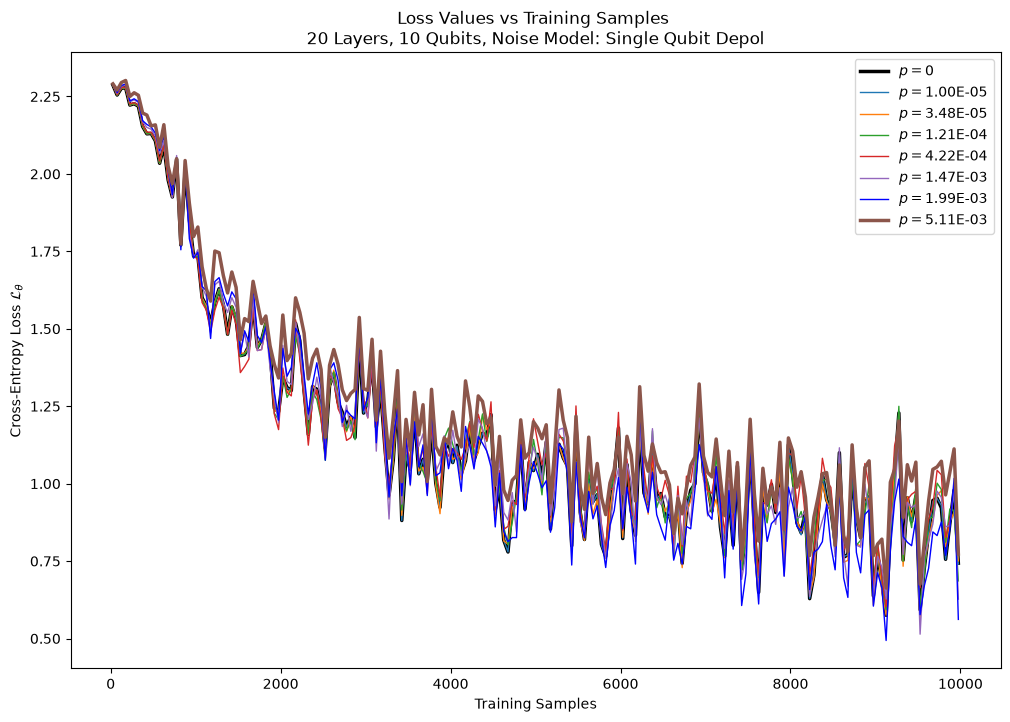

In [114]:
batches_size = 50 
plt.figure(figsize=(12, 8))
for data in training_data_list:
    batch_avg_loss_values      = TrainingData.batch_average(data.loss_values, batches_size)
    batch_avg_training_samples = TrainingData.batch_average(data.training_samples, batches_size)
    p_depol = data.noise_params.get("depolarising_noise", 0)
    label = f'$p=${p_depol:.2E}' if p_depol > 0 else '$p=0$'
    linewidth = 2.5 if (p_depol == 0 or p_depol > 5e-3) else 1
    plt.plot(batch_avg_training_samples, batch_avg_loss_values, label=label, color=colors[training_data_list.index(data)], linewidth=linewidth)
plt.xlabel('Training Samples')
plt.ylabel(r'Cross-Entropy Loss $\mathcal{L}_\theta$')
plt.legend()
plt.title(f'Loss Values vs Training Samples \n{training_data_list[0].layers} Layers, {training_data_list[0].num_qubits} Qubits, Noise Model: {training_data_list[1].noise_model_name}')
plt.savefig('plots/loss_vs_training_samples_batch_avg.pdf', dpi=300, bbox_inches='tight')
plt.show()

Depolarising Noise: 1.00E-05, Average Gradient: 1.5413E-03
Depolarising Noise: 3.48E-05, Average Gradient: 1.5021E-03
Depolarising Noise: 1.21E-04, Average Gradient: 1.5917E-03
Depolarising Noise: 4.22E-04, Average Gradient: 1.7553E-03
Depolarising Noise: 1.47E-03, Average Gradient: 1.2303E-03
Depolarising Noise: 1.99E-03, Average Gradient: 1.1412E-03
Depolarising Noise: 5.11E-03, Average Gradient: 1.1496E-03


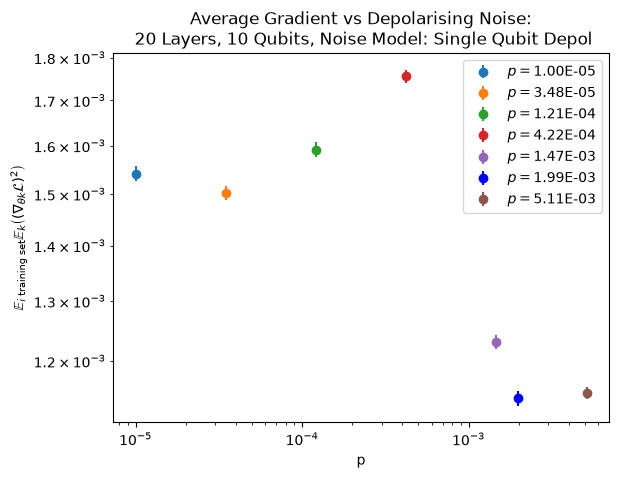

In [119]:
# This plot compares the average gradient value over all training samples vs the depolarising noise parameter for each training run.
for data in training_data_list[1:]:  # Skip the first entry since it has no depolarising noise
    avg_gradient = np.mean(data.gradients)
    avg_gradient_err = np.std(data.gradients) / np.sqrt(len(data.gradients))  # Standard error of the mean
    p_depol = data.noise_params.get("depolarising_noise", 0)
    label = f'$p=${p_depol:.2E}' if p_depol > 0 else '$p=0$'
    print(f"Depolarising Noise: {p_depol:.2E}, Average Gradient: {avg_gradient:.4E}")
    plt.errorbar(p_depol, avg_gradient, yerr=avg_gradient_err, fmt='o', label=label, color=colors[training_data_list.index(data)])
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'p')
plt.ylabel(r'$\mathbb{E}_{i~\text{training set}} \mathbb{E}_k \left( (\nabla_{\theta k} \mathcal{L})^2 \right)$')
plt.legend()
plt.title(f'Average Gradient vs Depolarising Noise:\n {training_data_list[0].layers} Layers, {training_data_list[0].num_qubits} Qubits, Noise Model: {training_data_list[1].noise_model_name}')
plt.savefig('plots/avg_gradient_vs_depol.pdf', dpi=300, bbox_inches='tight')
plt.show()


Depolarising Noise: 0.00E+00, Accuracy: 0.772000
Depolarising Noise: 1.00E-05, Accuracy: 0.772000
Depolarising Noise: 3.48E-05, Accuracy: 0.756000
Depolarising Noise: 1.21E-04, Accuracy: 0.776000
Depolarising Noise: 4.22E-04, Accuracy: 0.788000
Depolarising Noise: 1.47E-03, Accuracy: 0.800000
Depolarising Noise: 1.99E-03, Accuracy: 0.816000
Depolarising Noise: 5.11E-03, Accuracy: 0.760000


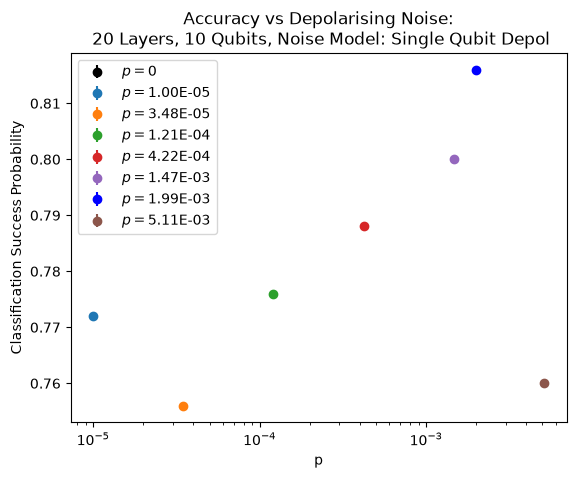

In [125]:

for data in training_data_list:  # Skip the first entry since it has no depolarising noise
    acc = max(data.accuracies.values())
    p_depol = data.noise_params.get("depolarising_noise", 0)
    label = f'$p=${p_depol:.2E}' if p_depol > 0 else '$p=0$'
    print(f"Depolarising Noise: {p_depol:.2E}, Accuracy: {acc:.6f}")
    plt.errorbar(p_depol, acc, yerr=0, fmt='o', label=label, color=colors[training_data_list.index(data)])
plt.xscale('log')
plt.xlabel(r'p')
plt.ylabel(r'Classification Success Probability')
plt.legend()
plt.title(f'Accuracy vs Depolarising Noise:\n {training_data_list[0].layers} Layers, {training_data_list[0].num_qubits} Qubits, Noise Model: {training_data_list[1].noise_model_name}')
plt.savefig('plots/accuracy_vs_depol.pdf', dpi=300, bbox_inches='tight')
plt.show()